# Portfolio Analysis: RR / BAE / GE / SAF

A 4-stock portfolio backtest built on live data pulled via `yfinance`. Covers Rolls-Royce (`RR.L`), BAE Systems (`BA.L`), General Electric (`GE`), and Safran (`SAF.PA`), converted to a common GBP base, weighted 40/30/20/10, and evaluated for cumulative return, volatility, correlation, and Sharpe ratio against the UK 10-year gilt yield as the risk-free rate.

**Note:** all data is pulled live at run time, so re-running this notebook on a different day will produce different numbers. The results below reflect one specific run (see README for the date).

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Pull data

Fetch 5 years of daily OHLC history for each holding, the current 10-year gilt yield (risk-free rate proxy), and the GBP/USD and GBP/EUR exchange rates needed to convert GE (USD) and SAF (EUR) into GBP.

In [2]:

rr = yf.Ticker("RR.L")
bae = yf.Ticker("BA.L")
ge = yf.Ticker("GE")
sa = yf.Ticker("SAF.PA")

#Get dataframes of 5 yr periods for each stock
dR = rr.history(period ="5y").drop(columns ='Dividends')
dB = bae.history(period ="5y").drop(columns ='Dividends')
dG = ge.history(period ="5y").drop(columns ='Dividends')
dS = sa.history(period ="5y").drop(columns ='Dividends')

#Getting Yield
gilt =yf.Ticker("10Y=F")
gilt_yield = gilt.info.get('regularMarketPrice')/100 
print(f"Current Gilt Risk-Free Rate: {gilt_yield}")

#Read in the exchange rate so we can convert the non UK companies to GBP
GUsd = yf.Ticker("GBPUSD=X").history(period = "5y")["Close"]
GEuro = yf.Ticker("GBPEUR=X").history(period = "5y")["Close"]

#User input start date
entry_date = pd.Timestamp("2022-02-03")
Initial_Value = int("100000")


Current Gilt Risk-Free Rate: 0.04771


## 2. Align dates and convert to GBP

Strip timezone info so all series can be compared/sliced consistently, trim every series to the chosen entry date, then convert GE and SAF closing prices into GBP using the FX series pulled above.

In [3]:
#Accounting for entry date
dR = dR.tz_localize(None).loc[entry_date:]
dB = dB.tz_localize(None).loc[entry_date:]
dG = dG.tz_localize(None).loc[entry_date:]
dS = dS.tz_localize(None).loc[entry_date:]
GUsd = GUsd.tz_localize(None).loc[entry_date:]
GEuro = GEuro.tz_localize(None).loc[entry_date:]
#Applying fx
for column in ['Open','Close','High','Low']:
    dG[column] = dG[column] / GUsd
    dS[column] = dS[column] / GEuro

## 3. Daily, cumulative, and annualized returns

Compute each stock's daily % return, compound it into a cumulative return series, and annualize it (252 trading days/year).

In [4]:
#Added a percentage change column
dR["Daily_return%"] = dR["Close"].pct_change(fill_method=None)*100
dB["Daily_return%"] = dB["Close"].pct_change(fill_method=None)*100
dG["Daily_return%"] = dG["Close"].pct_change(fill_method=None)*100
dS["Daily_return%"] = dS["Close"].pct_change(fill_method=None)*100
#Cumulative returns
dR["Growth_factor"] = dR["Daily_return%"]/100 +1 
dB["Growth_factor"] = dB["Daily_return%"]/100 +1 
dG["Growth_factor"] = dG["Daily_return%"]/100 +1 
dS["Growth_factor"] = dS["Daily_return%"]/100 +1 
dR["Cumulative Return"] = dR["Growth_factor"].cumprod()
dB["Cumulative Return"] = dB["Growth_factor"].cumprod()
dG["Cumulative Return"] = dG["Growth_factor"].cumprod()
dS["Cumulative Return"] = dS["Growth_factor"].cumprod()
#Annualized return column
nR = np.arange(1, len(dR) + 1)
nB = np.arange(1, len(dB) + 1)
nG = np.arange(1, len(dG) + 1)
nS = np.arange(1, len(dS) + 1)
dR["Annualized Return"] = (dR["Cumulative Return"]) ** (252/ nR) -1
dB["Annualized Return"] = (dB["Cumulative Return"]) ** (252/ nB) -1
dG["Annualized Return"] = (dG["Cumulative Return"]) ** (252/ nG) -1
dS["Annualized Return"] = (dS["Cumulative Return"]) ** (252/ nS) -1

## 4. Align trading calendars

RR.L, BA.L, GE, and SAF.PA sit on different exchanges with different holiday calendars, so trim every series down to the dates all four have in common — otherwise the portfolio math below would be misaligned.

In [5]:
#different stock exchanges have different holidays leading to diferent amounts of trading days, this evens the field
common_dates = dR.index.intersection(dB.index).intersection(dG.index).intersection(dS.index)
dR = dR.loc[common_dates]
dB = dB.loc[common_dates]
dG = dG.loc[common_dates]
dS = dS.loc[common_dates]

## 5. Build the portfolio

Apply the target weights (RR 40% / BAE 30% / GE 20% / SAF 10%) to the aligned daily returns to get the portfolio's daily and cumulative return series, and plot cumulative returns for each individual stock.

Text(0, 0.5, 'Growth Factor')

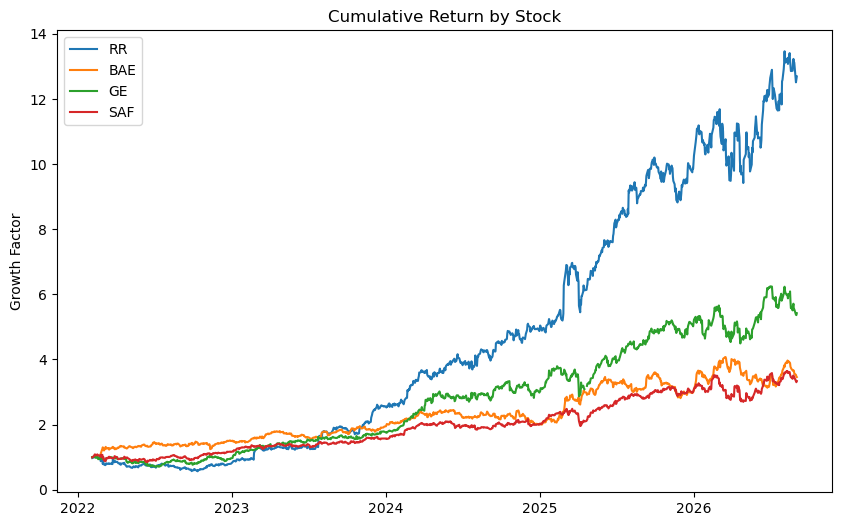

In [6]:
#Weighting of stocks in the portfolio
weights = {'RR': 0.40, 'BAE': 0.30, 'GE': 0.2, 'SAF': 0.1}
returns_stock = pd.DataFrame({
    'RR': dR['Daily_return%']/100 ,
    'BAE': dB['Daily_return%']/100,
    'GE': dG['Daily_return%']/100,
    'SAF': dS['Daily_return%']/100 
})
weights_series = pd.Series(weights)
portfolio_return = returns_stock.dot(weights_series) 
cumulative_return = ((1 + portfolio_return).cumprod() -1 ) 
n = np.arange(1, len(common_dates) + 1)
Annual_return = (cumulative_return ** (252/n)) -1
portfolio_return_annual = Annual_return.iloc[-1]
#Adding the portfolio return to the data frame
returns_portfolio = pd.DataFrame({
    'RR': dR['Daily_return%'] / 100,
    'BAE': dB['Daily_return%'] / 100,
    'GE': dG['Daily_return%'] / 100,
    'SAF': dS['Daily_return%'] / 100,
    'Net Portfolio': portfolio_return})
#Heres a plot of all the Stocks together
plt.figure(figsize=(10,6))
plt.plot(dR.index, dR['Cumulative Return'], label='RR')
plt.plot(dB.index, dB['Cumulative Return'], label='BAE')
plt.plot(dG.index, dG['Cumulative Return'], label='GE')
plt.plot(dS.index, dS['Cumulative Return'], label='SAF')
plt.legend()
plt.title('Cumulative Return by Stock')
plt.ylabel('Growth Factor')

## 6. Risk metrics: volatility, correlation, Sharpe ratio

Use the covariance matrix of the four return series plus the portfolio weights to get annualized portfolio volatility, then compute the Sharpe ratio using the gilt yield as the risk-free rate. The correlation matrix below shows how much diversification benefit the four holdings actually provide.

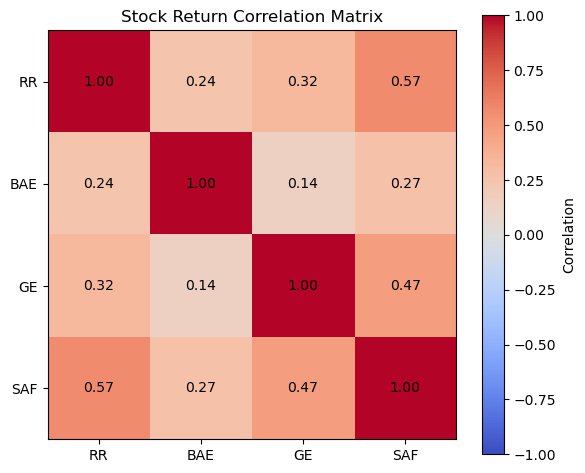

In [7]:
#Volatility metrics
#Calculating Volatility
cov_matrix = returns_stock[['RR', 'BAE', 'GE', 'SAF']].cov()
weights_array = np.array([weights['RR'], weights['BAE'], weights['GE'], weights['SAF']])
portfolio_variance = weights_array @ cov_matrix.values @ weights_array
portfolio_volatility = np.sqrt(portfolio_variance)
portfolio_volatility_annual = portfolio_volatility * np.sqrt(252)

Sharpe_Ratio = (portfolio_return_annual - gilt_yield)/ portfolio_volatility_annual


#Correlation matrix  - Acknowledge AI for assistance
corr_matrix = returns_stock[['RR', 'BAE', 'GE', 'SAF']].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Tick labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

# Annotate each cell with its correlation value
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

fig.colorbar(im, label='Correlation')
plt.title('Stock Return Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Results

Portfolio value over time (starting from an initial £100,000 investment), plus the headline gilt yield, total portfolio return, and Sharpe ratio.

**Sanity check:** the ~630% total return over this window is driven heavily by Rolls-Royce's post-COVID share price recovery — RR carries the largest weight (40%) and posted an exceptional run over this specific period. This is a real reflection of the chosen entry date and weights, not a calculation error, but it's worth flagging since it's an unusually large number for a 5-year backtest.

Gilt yield: 4.77%
Portfolio_return: 631.83%
Sharpe Ratio: 1.6


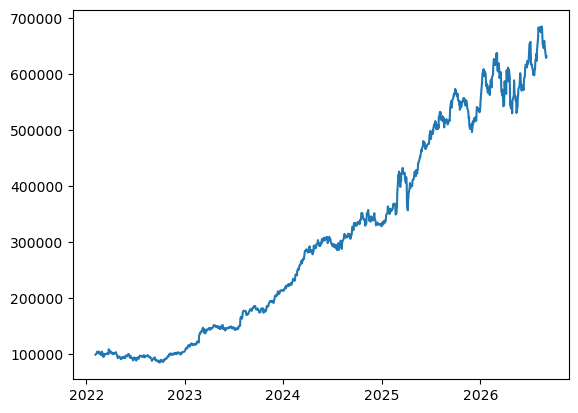

In [8]:
#Here's a plot of the portfolio + some key info
Portfolio_value = Initial_Value * (cumulative_return + 1)
plt.plot(common_dates, Portfolio_value)
PV= Portfolio_value.iloc[-1]/Initial_Value
print(f"Gilt yield: {gilt_yield:.2%}")
print(f"Portfolio_return: {PV:.2%}")
print(f"Sharpe Ratio: {Sharpe_Ratio:.2}")